<a href="https://colab.research.google.com/github/silviyax03/Medical-Abstract-Sentence-Classifier-using-PubMed-RCT/blob/main/Medical_Abstract_Sentence_Classifier_using_PubMed_RCT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

print(os.listdir("/content"))

['.config', 'test.txt', 'train.txt', 'dev.txt', 'sample_data']


In [3]:
# Read the first 30 lines of train.txt

with open("/content/train.txt", "r", encoding="utf-8") as file:
    for i in range(30):
        line = file.readline()
        print(line.strip())

###24293578
OBJECTIVE	To investigate the efficacy of 6 weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at 12 weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .
METHODS	A total of 125 patients with primary knee OA were randomized 1:1 ; 63 received 7.5 mg/day of prednisolone and 62 received placebo for 6 weeks .
METHODS	Outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .
METHODS	Pain was assessed using the visual analog pain scale ( 0-100 mm ) .
METHODS	Secondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and 6-min walk distance ( 6MWD ) .
METHODS	Serum levels of interleukin 1 ( IL-1 ) , IL-6 , tumor necrosis factor ( TNF ) - , and high-sensitivity C-reactive protein

In [4]:
# Convert the .txt files into DataFrames

import pandas as pd

def load_pubmed_data(file_path):
    data = []
    abstract_id = None

    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            # Skip empty lines
            if not line:
                continue

            # Abstract ID
            if line.startswith("###"):
                abstract_id = line.replace("###", "")

            # Sentence and label
            else:
                parts = line.split("\t", maxsplit=1)

                if len(parts) == 2:
                    label, sentence = parts

                    data.append({
                        "abstract_id": abstract_id,
                        "label": label,
                        "sentence": sentence
                    })

    return pd.DataFrame(data)

In [5]:
train_df = load_pubmed_data("/content/train.txt")
dev_df = load_pubmed_data("/content/dev.txt")
test_df = load_pubmed_data("/content/test.txt")

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)

Train shape: (180040, 3)
Dev shape: (30212, 3)
Test shape: (30135, 3)


In [6]:
train_df.head()

,abstract_id,label,sentence
0,24293578,OBJECTIVE,To investigate the efficacy of 6 weeks of dail...
1,24293578,METHODS,A total of 125 patients with primary knee OA w...
2,24293578,METHODS,Outcome measures included pain reduction and i...
3,24293578,METHODS,Pain was assessed using the visual analog pain...
4,24293578,METHODS,Secondary outcome measures included the Wester...


In [7]:
# Check the labels
train_df["label"].value_counts()

,count
label,
METHODS,59353
RESULTS,57953
CONCLUSIONS,27168
BACKGROUND,21727
OBJECTIVE,13839


In [8]:
# Check all unique labels
train_df["label"].unique()

array(['OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS', 'BACKGROUND'],
      dtype=object)

In [9]:
# Display the complete first sentence from the training dataset
train_df["sentence"].iloc[0]

'To investigate the efficacy of 6 weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at 12 weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .'

In [10]:
# Check for missing values in the training dataset
train_df.isnull().sum()

,0
abstract_id,0
label,0
sentence,0


In [11]:
# Count the number of unique abstracts in the training dataset
train_df["abstract_id"].nunique()

15000

In [12]:
# Count unique abstracts in each dataset

print("Training abstracts:", train_df["abstract_id"].nunique())
print("Validation abstracts:", dev_df["abstract_id"].nunique())
print("Test abstracts:", test_df["abstract_id"].nunique())

Training abstracts: 15000
Validation abstracts: 2500
Test abstracts: 2500


In [13]:
# Check the label distribution in the validation dataset
dev_df["label"].value_counts()

,count
label,
METHODS,9964
RESULTS,9841
CONCLUSIONS,4582
BACKGROUND,3449
OBJECTIVE,2376


In [14]:
# Check the label distribution in the test dataset
test_df["label"].value_counts()

,count
label,
METHODS,9897
RESULTS,9713
CONCLUSIONS,4571
BACKGROUND,3621
OBJECTIVE,2333


In [15]:
# Check the data types of each column
train_df.dtypes

,0
abstract_id,object
label,object
sentence,object


In [16]:
# Check for duplicate rows in the training dataset
train_df.duplicated().sum()

np.int64(9)

In [17]:
# Check whether any sentence appears with more than one label
sentence_label_counts = train_df.groupby("sentence")["label"].nunique()

print("Sentences with multiple labels:", (sentence_label_counts > 1).sum())

Sentences with multiple labels: 44


In [18]:
# Calculate the number of words in each sentence
train_df["word_count"] = train_df["sentence"].str.split().str.len()

# Display basic statistics of sentence length
train_df["word_count"].describe()

,word_count
count,180040.000000
mean,26.338436
std,15.386976
min,1.000000
25%,16.000000
50%,23.000000
75%,33.000000
max,296.000000


In [19]:
# Remove the temporary word_count column
train_df.drop("word_count", axis=1, inplace=True)

# Check the columns after removing it
train_df.columns

Index(['abstract_id', 'label', 'sentence'], dtype='object')

In [20]:
# Create input features and target labels

X_train = train_df["sentence"]
y_train = train_df["label"]

X_dev = dev_df["sentence"]
y_dev = dev_df["label"]

X_test = test_df["sentence"]
y_test = test_df["label"]

# Display the shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_dev:", X_dev.shape)
print("y_dev:", y_dev.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (180040,)
y_train: (180040,)
X_dev: (30212,)
y_dev: (30212,)
X_test: (30135,)
y_test: (30135,)


In [21]:
# Import TF-IDF vectorizer from scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer

print("TF-IDF imported successfully!")

TF-IDF imported successfully!


In [22]:
# Create the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2)
)

print("TF-IDF vectorizer created successfully!")

TF-IDF vectorizer created successfully!


In [23]:
# Learn the vocabulary and TF-IDF values from the training sentences
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Display the shape of the transformed training data
print("TF-IDF training shape:", X_train_tfidf.shape)

TF-IDF training shape: (180040, 50000)


In [24]:
# Transform the validation sentences using the fitted TF-IDF vectorizer
X_dev_tfidf = tfidf_vectorizer.transform(X_dev)

# Transform the test sentences using the fitted TF-IDF vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Display the shapes
print("TF-IDF validation shape:", X_dev_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF validation shape: (30212, 50000)
TF-IDF test shape: (30135, 50000)


In [25]:
# Import Logistic Regression from scikit-learn
from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported successfully!")

Logistic Regression imported successfully!


In [26]:
# Create the Logistic Regression baseline model
logistic_model = LogisticRegression(
    max_iter=1000
)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [27]:
# Train the Logistic Regression baseline model
logistic_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [28]:
# Predict the labels for the validation dataset
y_dev_pred = logistic_model.predict(X_dev_tfidf)

# Display the first 10 predictions
print(y_dev_pred[:10])

['BACKGROUND' 'BACKGROUND' 'OBJECTIVE' 'METHODS' 'METHODS' 'RESULTS'
 'RESULTS' 'RESULTS' 'RESULTS' 'CONCLUSIONS']


In [29]:
# Import metrics for evaluating the classification model
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [30]:
# Calculate the validation accuracy of the Logistic Regression model
dev_accuracy = accuracy_score(y_dev, y_dev_pred)

# Display the accuracy
print("Validation Accuracy:", dev_accuracy)

Validation Accuracy: 0.8311598040513704


In [31]:
# Calculate the Macro F1-score on the validation dataset
dev_macro_f1 = f1_score(
    y_dev,
    y_dev_pred,
    average="macro"
)

# Display the Macro F1-score
print("Validation Macro F1-score:", dev_macro_f1)

Validation Macro F1-score: 0.7671040093063002


In [32]:
# Generate the classification report for the validation dataset
print(classification_report(y_dev, y_dev_pred))

              precision    recall  f1-score   support

  BACKGROUND       0.65      0.67      0.66      3449
 CONCLUSIONS       0.77      0.76      0.76      4582
     METHODS       0.88      0.93      0.90      9964
   OBJECTIVE       0.72      0.54      0.62      2376
     RESULTS       0.89      0.89      0.89      9841

    accuracy                           0.83     30212
   macro avg       0.78      0.76      0.77     30212
weighted avg       0.83      0.83      0.83     30212



In [33]:
# Create the confusion matrix
cm = confusion_matrix(y_dev, y_dev_pred)

# Define the five class names in a fixed order
labels = [
    "BACKGROUND",
    "OBJECTIVE",
    "METHODS",
    "RESULTS",
    "CONCLUSIONS"
]

# Display the confusion matrix
print(cm)

[[2302  459  275  377   36]
 [ 371 3467  149   44  551]
 [ 113   75 9258   70  448]
 [ 724  177  173 1278   24]
 [  27  329  678    1 8806]]


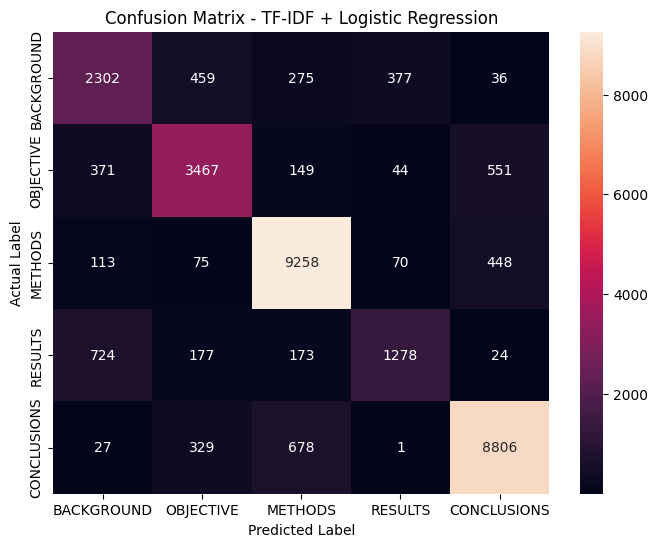

In [34]:
# Import matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Create the confusion matrix heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

# Add chart labels
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - TF-IDF + Logistic Regression")

# Display the plot
plt.show()

In [35]:
# Import TensorFlow for building neural NLP models
import tensorflow as tf

# Display the TensorFlow version
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [36]:
# Import TextVectorization for converting text into integer sequences
from tensorflow.keras.layers import TextVectorization

# Confirm the import was successful
print("TextVectorization imported successfully!")

TextVectorization imported successfully!


In [37]:
# Create the TextVectorization layer
text_vectorizer = TextVectorization(
    max_tokens=50000,
    output_mode="int",
    output_sequence_length=50
)

# Confirm the vectorizer was created
print("Text vectorizer created successfully!")

Text vectorizer created successfully!


In [38]:
# Learn the vocabulary from the training sentences
text_vectorizer.adapt(X_train)


print("Vocabulary created successfully!")

Vocabulary created successfully!


In [39]:
# Check the vocabulary learned from the training data
vocabulary = text_vectorizer.get_vocabulary()

print("Vocabulary size:", len(vocabulary))

print("\nFirst 20 tokens:")
print(vocabulary[:20])

Vocabulary size: 50000

First 20 tokens:
['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('of'), np.str_('in'), np.str_('to'), np.str_('with'), np.str_('a'), np.str_('were'), np.str_('was'), np.str_('for'), np.str_('patients'), np.str_('group'), np.str_('p'), np.str_('at'), np.str_('or'), np.str_('study'), np.str_('on'), np.str_('treatment')]


In [40]:
# Convert the first training sentence into a sequence of token IDs
sample_sequence = text_vectorizer(X_train.iloc[0])

print("Original sentence:")
print(X_train.iloc[0])

print("\nToken sequence:")
print(sample_sequence)

Original sentence:
To investigate the efficacy of 6 weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at 12 weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .

Token sequence:
tf.Tensor(
[   6  356    2   82    4   72   65    4  172 1231  226 2761    5  604
   66 1724    3  730 6164  690    5    2  714 1241    3  190    2   71
  534   37  848   15   76   65    5  380  278    7  389    6  308  557
 1564 1895    0    0    0    0    0    0], shape=(50,), dtype=int64)


In [41]:
# Convert all sentences into fixed-length integer sequences
X_train_seq = text_vectorizer(X_train)
X_dev_seq = text_vectorizer(X_dev)
X_test_seq = text_vectorizer(X_test)

print("Training sequence shape:", X_train_seq.shape)
print("Validation sequence shape:", X_dev_seq.shape)
print("Test sequence shape:", X_test_seq.shape)

Training sequence shape: (180040, 50)
Validation sequence shape: (30212, 50)
Test sequence shape: (30135, 50)


In [42]:
from sklearn.preprocessing import LabelEncoder

# Convert the five text labels into integer values
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_dev_encoded = label_encoder.transform(y_dev)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)
print("Encoded labels:", sorted(set(y_train_encoded)))

Classes: ['BACKGROUND' 'CONCLUSIONS' 'METHODS' 'OBJECTIVE' 'RESULTS']
Encoded labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

print("Text-CNN layers imported successfully!")

Text-CNN layers imported successfully!


In [45]:
# Build the Text-CNN model without the deprecated input_length argument
text_cnn_model = Sequential([
    Embedding(input_dim=50000, output_dim=128),
    Conv1D(filters=128, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(5, activation="softmax")
])

print("Text-CNN model created successfully!")

Text-CNN model created successfully!


In [46]:
# Configure the Text-CNN model for training
text_cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Text-CNN model compiled successfully!")

Text-CNN model compiled successfully!


In [47]:
# Display the Text-CNN architecture
text_cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Rebuild the Text-CNN model with an explicit input shape
text_cnn_model = Sequential([
    tf.keras.Input(shape=(50,)),
    Embedding(input_dim=50000, output_dim=128),
    Conv1D(filters=128, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(5, activation="softmax")
])

# Compile the model again after rebuilding it
text_cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Text-CNN model rebuilt and compiled successfully!")

Text-CNN model rebuilt and compiled successfully!


In [49]:
# Display the updated Text-CNN architecture
text_cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 128)        │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,490,629 (24.76 MB)

 Trainable params: 6,490,629 (24.76 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Train the Text-CNN using the training data
cnn_history = text_cnn_model.fit(
    X_train_seq,
    y_train_encoded,
    validation_data=(X_dev_seq, y_dev_encoded),
    epochs=5,
    batch_size=64
)

Epoch 1/5
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 327s 115ms/step - accuracy: 0.7743 - loss: 0.6170 - val_accuracy: 0.8286 - val_loss: 0.4687
Epoch 2/5
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 307s 109ms/step - accuracy: 0.8531 - loss: 0.4155 - val_accuracy: 0.8288 - val_loss: 0.4756
Epoch 3/5
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 313s 111ms/step - accuracy: 0.8977 - loss: 0.2897 - val_accuracy: 0.8220 - val_loss: 0.5452
Epoch 4/5
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 323s 112ms/step - accuracy: 0.9330 - loss: 0.1915 - val_accuracy: 0.8157 - val_loss: 0.6451
Epoch 5/5
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 321s 111ms/step - accuracy: 0.9562 - loss: 0.1270 - val_accuracy: 0.8072 - val_loss: 0.8427


In [52]:
# Generate Text-CNN predictions for the validation dataset
cnn_predictions = text_cnn_model.predict(X_dev_seq)

# Convert probability predictions into class labels
y_dev_cnn_pred = cnn_predictions.argmax(axis=1)

print("Text-CNN predictions generated successfully!")

945/945 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step
Text-CNN predictions generated successfully!


In [53]:
# Calculate Text-CNN validation accuracy
cnn_accuracy = accuracy_score(y_dev_encoded, y_dev_cnn_pred)

print("Text-CNN Validation Accuracy:", cnn_accuracy)

Text-CNN Validation Accuracy: 0.807162716801271


In [54]:
# Calculate Text-CNN Macro F1-score
cnn_macro_f1 = f1_score(
    y_dev_encoded,
    y_dev_cnn_pred,
    average="macro"
)

print("Text-CNN Validation Macro F1-score:", cnn_macro_f1)

Text-CNN Validation Macro F1-score: 0.7399744234554886


In [55]:
# Generate the Text-CNN classification report
print(
    classification_report(
        y_dev_encoded,
        y_dev_cnn_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  BACKGROUND       0.60      0.67      0.63      3449
 CONCLUSIONS       0.76      0.68      0.72      4582
     METHODS       0.88      0.91      0.90      9964
   OBJECTIVE       0.63      0.54      0.58      2376
     RESULTS       0.87      0.87      0.87      9841

    accuracy                           0.81     30212
   macro avg       0.75      0.74      0.74     30212
weighted avg       0.81      0.81      0.81     30212



In [56]:
from tensorflow.keras.layers import LSTM, Bidirectional

print("BiLSTM layers imported successfully!")

BiLSTM layers imported successfully!


In [57]:
# Build the BiLSTM model
bilstm_model = Sequential([
    tf.keras.Input(shape=(50,)),
    Embedding(input_dim=50000, output_dim=128),
    Bidirectional(LSTM(64)),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(5, activation="softmax")
])

print("BiLSTM model created successfully!")

BiLSTM model created successfully!


In [58]:
# Display the BiLSTM model architecture
bilstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 128)        │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,507,397 (24.82 MB)

 Trainable params: 6,507,397 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
# Configure the BiLSTM model for training
bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("BiLSTM model compiled successfully!")

BiLSTM model compiled successfully!


In [60]:
# Train the BiLSTM using the training dataset
bilstm_history = bilstm_model.fit(
    X_train_seq,
    y_train_encoded,
    validation_data=(X_dev_seq, y_dev_encoded),
    epochs=5,
    batch_size=64
)

Epoch 1/5
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 538s 190ms/step - accuracy: 0.7829 - loss: 0.5970 - val_accuracy: 0.8189 - val_loss: 0.4826
Epoch 2/5
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 560s 189ms/step - accuracy: 0.8521 - loss: 0.4223 - val_accuracy: 0.8294 - val_loss: 0.4650
Epoch 3/5
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 553s 186ms/step - accuracy: 0.8849 - loss: 0.3318 - val_accuracy: 0.8246 - val_loss: 0.5050
Epoch 4/5
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 530s 188ms/step - accuracy: 0.9125 - loss: 0.2576 - val_accuracy: 0.8181 - val_loss: 0.5745
Epoch 5/5
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 536s 190ms/step - accuracy: 0.9342 - loss: 0.1933 - val_accuracy: 0.8140 - val_loss: 0.6872


In [61]:
# Generate BiLSTM predictions for the validation dataset
bilstm_predictions = bilstm_model.predict(X_dev_seq)

# Convert predicted probabilities into class labels
y_dev_bilstm_pred = bilstm_predictions.argmax(axis=1)

print("BiLSTM predictions generated successfully!")

945/945 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step
BiLSTM predictions generated successfully!


In [62]:
# Calculate BiLSTM validation accuracy
bilstm_accuracy = accuracy_score(y_dev_encoded, y_dev_bilstm_pred)

print("BiLSTM Validation Accuracy:", bilstm_accuracy)

BiLSTM Validation Accuracy: 0.8139811995233682


In [63]:
# Calculate BiLSTM Macro F1-score
bilstm_macro_f1 = f1_score(
    y_dev_encoded,
    y_dev_bilstm_pred,
    average="macro"
)

print("BiLSTM Validation Macro F1-score:", bilstm_macro_f1)

BiLSTM Validation Macro F1-score: 0.7507408277693802


In [64]:
# Generate the BiLSTM classification report
print(
    classification_report(
        y_dev_encoded,
        y_dev_bilstm_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  BACKGROUND       0.60      0.70      0.64      3449
 CONCLUSIONS       0.75      0.70      0.72      4582
     METHODS       0.90      0.90      0.90      9964
   OBJECTIVE       0.68      0.55      0.61      2376
     RESULTS       0.87      0.88      0.88      9841

    accuracy                           0.81     30212
   macro avg       0.76      0.75      0.75     30212
weighted avg       0.82      0.81      0.81     30212



In [66]:
# Display variables related to the Logistic Regression model
[name for name in globals() if "log" in name.lower()]

['LogisticRegression', 'logistic_model']

In [67]:
# Generate predictions on the unseen test dataset
y_test_pred = logistic_model.predict(X_test_tfidf)

print("Test predictions generated successfully!")

Test predictions generated successfully!


In [68]:
# Calculate final test performance
test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")

print("Test Accuracy:", test_accuracy)
print("Test Macro F1-score:", test_macro_f1)

Test Accuracy: 0.8229301476688237
Test Macro F1-score: 0.7598119200469368


In [69]:
# Generate the final classification report on the test dataset
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  BACKGROUND       0.66      0.66      0.66      3621
 CONCLUSIONS       0.76      0.75      0.75      4571
     METHODS       0.87      0.93      0.90      9897
   OBJECTIVE       0.71      0.53      0.61      2333
     RESULTS       0.88      0.88      0.88      9713

    accuracy                           0.82     30135
   macro avg       0.78      0.75      0.76     30135
weighted avg       0.82      0.82      0.82     30135



In [70]:
# Create the confusion matrix for the final test predictions
test_cm = confusion_matrix(y_test, y_test_pred)

print(test_cm)

[[2382  493  314  390   42]
 [ 377 3416  142   41  595]
 [ 111   82 9174   66  464]
 [ 727  172  170 1237   27]
 [  35  347  738    3 8590]]


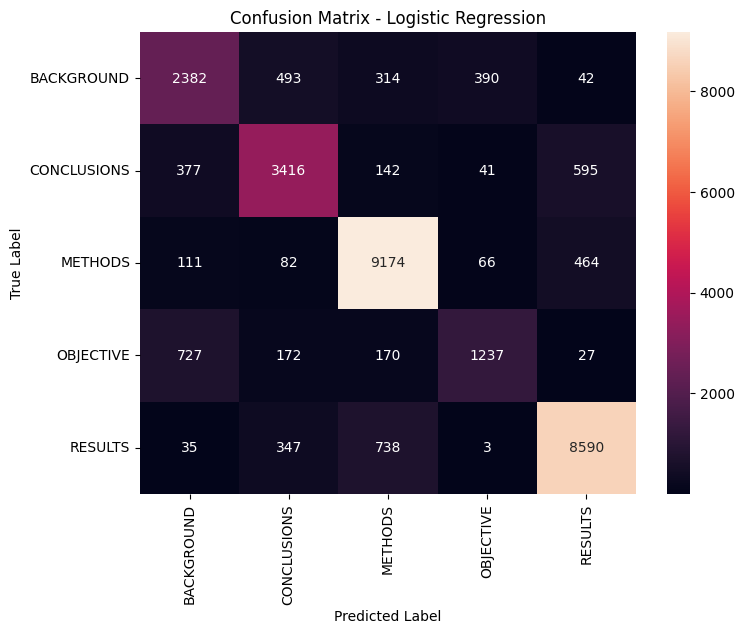

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = label_encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [72]:
def classify_sentence(sentence):
    sentence_tfidf = tfidf_vectorizer.transform([sentence])
    prediction = logistic_model.predict(sentence_tfidf)[0]
    return prediction

print("Sentence classification function created successfully!")

Sentence classification function created successfully!


In [73]:
test_sentence = "The study was conducted to evaluate the effectiveness of the treatment."

prediction = classify_sentence(test_sentence)

print("Sentence:", test_sentence)
print("Predicted role:", prediction)

Sentence: The study was conducted to evaluate the effectiveness of the treatment.
Predicted role: OBJECTIVE


In [74]:
import re

def classify_abstract(abstract):
    sentences = re.split(r'(?<=[.!?])\s+', abstract.strip())

    results = []

    for sentence in sentences:
        if sentence.strip():
            prediction = classify_sentence(sentence)
            results.append((sentence.strip(), prediction))

    return results

print("Abstract classification function created successfully!")

Abstract classification function created successfully!


In [75]:
# Get all sentences belonging to the first abstract
sample_abstract_df = train_df[
    train_df["abstract_id"] == train_df["abstract_id"].iloc[0]
]

sample_abstract = " ".join(sample_abstract_df["sentence"].tolist())

print(sample_abstract)

To investigate the efficacy of 6 weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at 12 weeks in older adults with moderate to severe knee osteoarthritis ( OA ) . A total of 125 patients with primary knee OA were randomized 1:1 ; 63 received 7.5 mg/day of prednisolone and 62 received placebo for 6 weeks . Outcome measures included pain reduction and improvement in function scores and systemic inflammation markers . Pain was assessed using the visual analog pain scale ( 0-100 mm ) . Secondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and 6-min walk distance ( 6MWD ) . Serum levels of interleukin 1 ( IL-1 ) , IL-6 , tumor necrosis factor ( TNF ) - , and high-sensitivity C-reactive protein ( hsCRP ) were measured . There was a clinically relevant red

In [76]:
# Classify each sentence in the sample abstract
classified_abstract = classify_abstract(sample_abstract)

for sentence, prediction in classified_abstract:
    print(f"[{prediction}] {sentence}\n")

[OBJECTIVE] To investigate the efficacy of 6 weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at 12 weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .

[METHODS] A total of 125 patients with primary knee OA were randomized 1:1 ; 63 received 7.5 mg/day of prednisolone and 62 received placebo for 6 weeks .

[METHODS] Outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .

[METHODS] Pain was assessed using the visual analog pain scale ( 0-100 mm ) .

[METHODS] Secondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and 6-min walk distance ( 6MWD ) .

[METHODS] Serum levels of interleukin 1 ( IL-1 ) , IL-6 , tumor necrosis factor ( TNF ) - , and high-sensitivity C-reactive pr

In [77]:
from IPython.display import HTML, display

role_colors = {
    "BACKGROUND": "#FFF3CD",
    "OBJECTIVE": "#D1ECF1",
    "METHODS": "#D4EDDA",
    "RESULTS": "#E2D9F3",
    "CONCLUSIONS": "#F8D7DA"
}

html_output = ""

for sentence, prediction in classified_abstract:
    color = role_colors[prediction]
    html_output += (
        f'<p style="background-color:{color}; padding:10px; '
        f'border-radius:6px; margin:6px 0;">'
        f'<b>{prediction}</b> — {sentence}</p>'
    )

display(HTML(html_output))

In [78]:
import joblib

# Save the trained Logistic Regression model and TF-IDF vectorizer
joblib.dump(logistic_model, "/content/logistic_model.pkl")
joblib.dump(tfidf_vectorizer, "/content/tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


In [79]:
import os

# Verify that both saved files exist
print("Logistic Regression model:", os.path.exists("/content/logistic_model.pkl"))
print("TF-IDF vectorizer:", os.path.exists("/content/tfidf_vectorizer.pkl"))

Logistic Regression model: True
TF-IDF vectorizer: True


In [81]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 97.9 MB/s eta 0:00:00


In [82]:
import streamlit
print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.62.0


In [109]:
%%writefile app.py

import streamlit as st
import joblib
import re

# Load trained model and TF-IDF vectorizer
logistic_model = joblib.load("logistic_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")

# Page configuration
st.set_page_config(
    page_title="PubMed Abstract Classifier",
    page_icon="📄",
    layout="wide"
)

# -----------------------------
# Custom CSS - Appearance only
# -----------------------------
st.markdown("""
<style>

    /* Main title */
    .main-title {
        font-size: 38px;
        font-weight: 700;
        margin-bottom: 5px;
    }

    /* Subtitle */
    .subtitle {
        font-size: 17px;
        color: #666666;
        margin-bottom: 25px;
    }

    /* Text area */
    textarea {
        border-radius: 10px !important;
    }

    /* Button */
    .stButton > button {
        border-radius: 8px;
        font-weight: 600;
        padding: 8px 22px;
    }

    /* Sidebar heading */
    [data-testid="stSidebar"] h2 {
        font-weight: 700;
    }

</style>
""", unsafe_allow_html=True)


# -----------------------------
# Header
# -----------------------------

st.markdown(
    '<div class="main-title">📄 PubMed Abstract Sentence Classifier</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">'
    'Classify sentences from medical abstracts into their research roles.'
    '</div>',
    unsafe_allow_html=True
)


# -----------------------------
# Label colors
# -----------------------------

role_colors = {
    "BACKGROUND": "#FFF3CD",
    "OBJECTIVE": "#D1ECF1",
    "METHODS": "#D4EDDA",
    "RESULTS": "#E2D9F3",
    "CONCLUSIONS": "#F8D7DA"
}


# -----------------------------
# Abstract input
# -----------------------------

abstract = st.text_area(
    "📝 Enter a medical abstract:",
    height=300,
    placeholder="Paste your medical abstract here..."
)


# -----------------------------
# Classification
# -----------------------------

if st.button("🔍 Classify Abstract"):

    if not abstract.strip():

        st.warning("Please enter a medical abstract.")

    else:

        sentences = re.split(
            r'(?<=[.!?])\s+',
            abstract.strip()
        )

        st.subheader("📊 Classification Results")

        for sentence in sentences:

            if sentence.strip():

                sentence_tfidf = tfidf_vectorizer.transform(
                    [sentence]
                )

                prediction = logistic_model.predict(
                    sentence_tfidf
                )[0]

                color = role_colors.get(
                    prediction,
                    "#FFFFFF"
                )

                # Original working result design
                st.markdown(
                    f"""
                    <div style="
                        background-color: {color};
                        padding: 12px;
                        border-radius: 8px;
                        margin-bottom: 10px;
                    ">
                        <strong>{prediction}</strong><br>
                        {sentence}
                    </div>
                    """,
                    unsafe_allow_html=True
                )


# -----------------------------
# Sidebar
# -----------------------------

st.sidebar.header("🏷️ Label Guide")

st.sidebar.write(
    "Each sentence is classified into one of five "
    "research roles:"
)

for role, color in role_colors.items():

    st.sidebar.markdown(
        f"""
        <div style="
            background-color: {color};
            padding: 8px;
            border-radius: 6px;
            margin-bottom: 5px;
        ">
            <strong>{role}</strong>
        </div>
        """,
        unsafe_allow_html=True
    )

st.sidebar.divider()

st.sidebar.subheader("🤖 Model")

st.sidebar.write(
    "TF-IDF + Logistic Regression"
)

st.sidebar.caption(
    "Selected based on the best test performance "
    "among the evaluated models."
)

Overwriting app.py


In [110]:
import os

print("app.py:", os.path.exists("app.py"))
print("logistic_model.pkl:", os.path.exists("logistic_model.pkl"))
print("tfidf_vectorizer.pkl:", os.path.exists("tfidf_vectorizer.pkl"))

app.py: True
logistic_model.pkl: True
tfidf_vectorizer.pkl: True


In [117]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

print("cloudflared installed successfully!")

cloudflared installed successfully!


In [118]:
!ls -lh /content/cloudflared

-rwxr-xr-x 1 root root 38M Aug 14 12:24 /content/cloudflared


In [119]:
!nohup /content/cloudflared tunnel --url http://localhost:8501 > /content/cloudflared.log 2>&1 &

In [122]:
!cat /content/cloudflared.log

2026-08-30T10:00:00Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-30T10:00:00Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-30T10:00:06Z INF +--------------------------------------------------------------------------------------------+
2026-08-30T10:00:06Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-30T10:00:06Z INF |  https://pts-cellular-gamecube-voluntary.trycloudflare

In [97]:
# Get the first 10 unique abstracts
abstract_ids = train_df["abstract_id"].unique()[:10]

for i, abstract_id in enumerate(abstract_ids, 1):
    abstract_df = train_df[train_df["abstract_id"] == abstract_id]

    abstract = " ".join(abstract_df["sentence"].tolist())

    print(f"\n{'='*80}")
    print(f"ABSTRACT {i}")
    print(f"{'='*80}")
    print(abstract)


ABSTRACT 1
To investigate the efficacy of 6 weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at 12 weeks in older adults with moderate to severe knee osteoarthritis ( OA ) . A total of 125 patients with primary knee OA were randomized 1:1 ; 63 received 7.5 mg/day of prednisolone and 62 received placebo for 6 weeks . Outcome measures included pain reduction and improvement in function scores and systemic inflammation markers . Pain was assessed using the visual analog pain scale ( 0-100 mm ) . Secondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and 6-min walk distance ( 6MWD ) . Serum levels of interleukin 1 ( IL-1 ) , IL-6 , tumor necrosis factor ( TNF ) - , and high-sensitivity C-reactive protein ( hsCRP ) were measured . There was a clinically 

In [98]:
# Get the first 10 unique abstracts
abstract_ids = train_df["abstract_id"].unique()[:10]

sample_abstracts = []

for abstract_id in abstract_ids:
    abstract_df = train_df[train_df["abstract_id"] == abstract_id]
    abstract = " ".join(abstract_df["sentence"].tolist())
    sample_abstracts.append(abstract)

print("Number of abstracts:", len(sample_abstracts))

Number of abstracts: 10


In [100]:
print(sample_abstracts[9])

Youths with a family history of alcohol and other drug use disorders ( FH + ) are at a greater risk of developing substance use disorders than their peers with no such family histories ( FH - ) , and this increased risk may be related to impaired maturation of forebrain circuitry . FH + individuals have shown altered forebrain activity at rest and while performing cognitive tasks . However , it is not fully understood how forebrain activity is altered in FH + individuals , and ultimately how these alterations may contribute to substance use disorder risk . In this study , we tested 72 FH + and 32 FH - youths performing a go/no-go task and examined activations in blocks with only go trials ( Go Only ) , blocks with 50 % go and 50 % no-go trials ( Go/NoGo ) , and a contrast of those 2 blocks . FH + youths had significantly greater cerebral activations in both the Go and Go/NoGo blocks than FH - youths in regions including the posterior cingulate/precuneus , bilateral middle/superior temp

In [123]:
%%writefile requirements.txt

streamlit==1.62.0
scikit-learn
joblib
pandas

Writing requirements.txt


In [124]:
import os

files = [
    "app.py",
    "logistic_model.pkl",
    "tfidf_vectorizer.pkl",
    "requirements.txt"
]

for file in files:
    print(file, ":", os.path.exists(file))

app.py : True
logistic_model.pkl : True
tfidf_vectorizer.pkl : True
requirements.txt : True
